<a href="https://colab.research.google.com/github/gien-7/progetto_GraphColouring_ML26/blob/main/Notebook_GNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# crea il folder data e download il dataset
import os

success = os.path.exists("data")
if not success:
  os.makedirs("data")

success = os.path.exists("data/x_all_08011.npy")
if not success:
  !wget http://giagu.web.cern.ch/giagu/CERN/x_all_08011.npy -P data/
  !wget http://giagu.web.cern.ch/giagu/CERN/y_all_08011.npy -P data/

In [ ]:
!ls -lh  data/

total 40M
-rw-r--r-- 1 root root  40M May  3 15:07 x_all_08011.npy
-rw-r--r-- 1 root root 626K May  3 15:06 y_all_08011.npy


**Leggiamo i dati, controlliamo il formato (shape), e plottiamo un esempio di immagine**

*   i dati sono in formato numpy, possono essere letti con la funzione *np.load*
*   printiamo la shape dei vettori numpy letti e il tipo di variabile
*   usiamo matplotlib *plt.imshow()* o *plt.matshow* per plottare un elemento dell array



In [ ]:
import numpy as np


x_all = np.load('data/x_all_08011.npy')
y_all = np.load('data/y_all_08011.npy')

print('Shape immagini: ',x_all.shape)
print('Shape label: ',y_all.shape)
print('Tipo immagini: ', x_all.dtype)
print('Tipo label: ', y_all.dtype)

Shape immagini:  (20000, 16, 16)
Shape label:  (20000, 4)
Tipo immagini:  float64
Tipo label:  float64


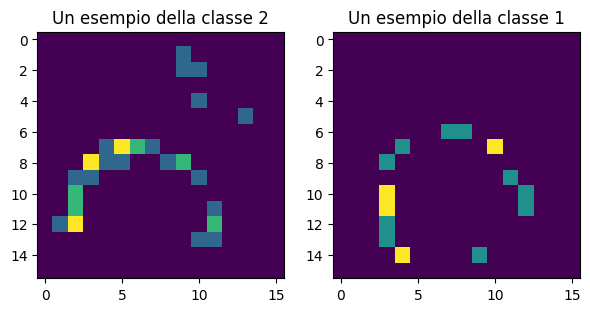

In [ ]:
import matplotlib.pyplot as plt

# plottiamo due immagini idx=0 e idx=10
idx1 = 0
idx2 = 10
plt.figure(figsize=(7,5))
plt.subplot(1,2,1)
plt.imshow(x_all[idx1,:,:])
plt.title("Un esempio della classe {}".format(np.argmax(y_all[idx1])))
plt.subplot(1,2,2)
plt.imshow(x_all[idx2,:,:])
plt.title("Un esempio della classe {}".format(np.argmax(y_all[idx2])))
plt.show()

**Analisi delle immagini**

plottiamo l'istogramma dell'intensità media per classe delle immagini. Costruiamo una funzione atta allo scopo

deve essere [N,1] :  (20000,)


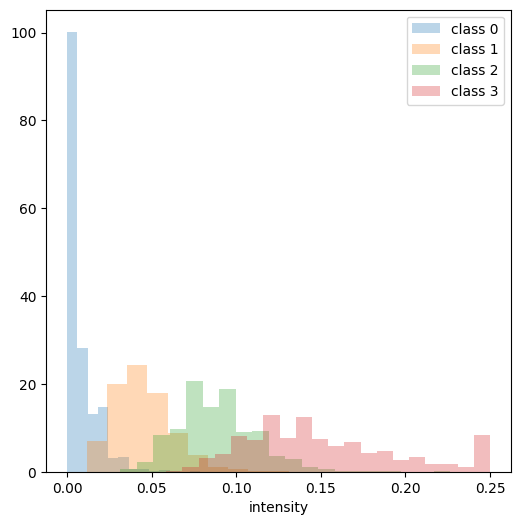

In [ ]:
def plot_histointensity(x, y):

  classes = np.argmax(y, axis=1) #ritorna l'indice del massimo valore di un array lungo la dimensione axis

  intensities = x.reshape(x.shape[0],-1).mean(axis=1) # [N,16,16] -> [N,16*16] e poi fa la media lungo la dimensione axis (axis=1 -> secnodna dimensione)
  print("deve essere [N,1] : ",intensities.shape)

  f,ax = plt.subplots(1,1,figsize=(6,6))
  for c in [0,1,2,3]:
    ax.hist(intensities[classes==c],20,alpha=0.3,label="class {}".format(c),density=True)

  ax.set_xlabel("intensity")
  ax.legend()

plot_histointensity(x_all, y_all)

deve essere [N,1] :  (18402,)


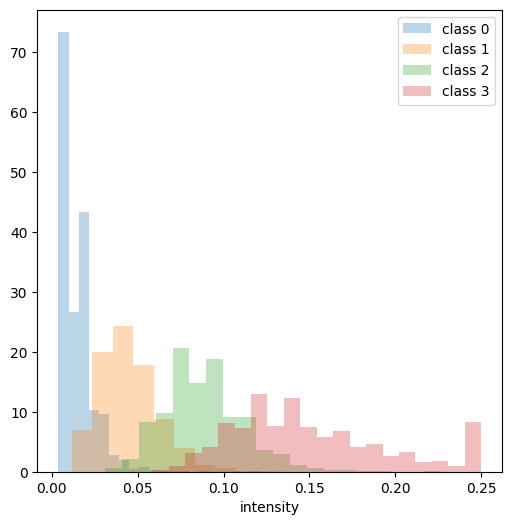

In [ ]:
# rimuoviamo le immagini totalmente vuote (non sono utili, qualsiasi operazione su un array di zeri è banale, inoltre già sappiamo che nessun segnale significa nessuna particella

def remove_empty(x, y):
  intensities = x.reshape(x.shape[0],-1).sum(axis=1)
  y_tmp = y[intensities>0]
  x_tmp = x[intensities>0]
  return x_tmp, y_tmp

x_all, y_all = remove_empty(x_all, y_all)
plot_histointensity(x_all, y_all)

**Analisi delle immagini**

plottiamo la distribuzione delle classi son un istogramma a torta

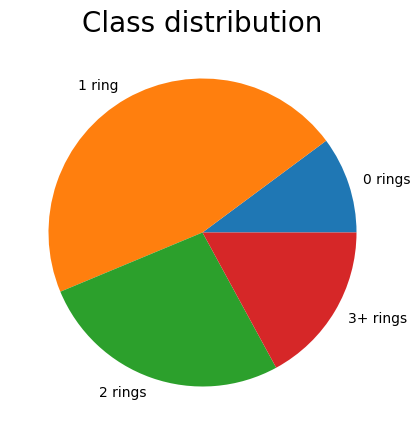

In [ ]:
# definiamo la finzione piechartclasses

def piechartclasses(y):
  classes = np.argmax(y, axis=1)
  c = np.unique(classes) #ritorna gli elementi unici di un array (ordinati)
  arr_c = [np.mean(classes==i) for i in c]


  fig = plt.figure(figsize =(8, 5))
  plt.pie(arr_c, labels = ["0 rings", "1 ring", "2 rings", "3+ rings"])
  plt.title("Class distribution",fontsize=20)
  plt.show()

piechartclasses(y_all)

**Convertiamo i dati in grafi torch-geometric, creiamo dataset e dataloader e facciamo data-augmentation**

Rispetto al notebook CNN, la differenza principale è questa: invece di restituire un tensore immagine `(1,16,16)`, il dataset restituisce un oggetto `torch_geometric.data.Data` con nodi, archi, feature, posizioni e label.


In [ ]:
import sys
import subprocess
import importlib.util

# Cambiamento rispetto alla CNN: serve torch_geometric per rappresentare eventi come grafi e per usare il DataLoader di PyG.
#
if importlib.util.find_spec("torch_geometric") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch-geometric"])

from torch.utils.data import Dataset
import torch
import torch.utils.data as data
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

# data augmentation: manteniamo le stesse trasformazioni del notebook CNN, perché vogliamo cambiare solo la rappresentazione dei dati.

# rimozione di un hit
def remove_a_hit(image):
  if image.sum()<3:
    return image
  a,b = np.nonzero(image) # ritorna due vettori (uno per ogni dimensione) corrispondenti agli elementi non zero
  i = np.random.randint(0,len(a))
  image[a[i],b[i]] -=1
  return image

# aggiunge un hit
def add_a_hit(image):
  image[np.random.randint(0,16),np.random.randint(0,16)] +=1
  return image

# flip tutti gli hit
def flip_hit(image):
  if np.random.rand()>0.5:
    image= np.fliplr(image) #rovescia l'ordine degli elementi lungo left-right
  else:
    image= np.flipud(image)  #rovescia l'ordine degli elementi lungo up-down
  return image

# sovrappone due immagini
def sum_images(image,lab,image2,lab2):
  lab=np.argmax(lab)
  lab2=np.argmax(lab2)
  image = image + image2
  lab = lab + lab2
  if lab>3:
    lab=3
  lab_tmp = np.zeros(4)
  lab_tmp[lab]=1

  return image,lab_tmp


def build_knn_edges(pos, k=4):
    """Costruisce edge_index in formato PyG usando i k vicini più prossimi.

    Cambiamento rispetto alla CNN: il vicinato locale non è più definito da kernel convoluzionali su griglia,
    ma da archi tra hit vicini nello spazio del rivelatore. Usiamo archi diretti nel formato standard PyG.
    """
    num_nodes = pos.size(0)
    if num_nodes <= 1:
        return torch.empty((2, 0), dtype=torch.long)

    k_eff = min(k, num_nodes - 1)
    dist = torch.cdist(pos, pos)
    dist.fill_diagonal_(float("inf"))
    nn_index = dist.topk(k_eff, largest=False).indices  # [num_nodes, k_eff]

    # edge_index[0] = sorgente, edge_index[1] = destinazione.
    # Per ogni nodo destinazione, i sorgenti sono i suoi k vicini più prossimi.
    row = nn_index.reshape(-1)
    col = torch.arange(num_nodes).repeat_interleave(k_eff)
    edge_index = torch.stack([row, col], dim=0).long()
    return edge_index


# creiamo una Dataset in torch. In questo esempio non usiamo i torch  Dataset usati negli esempi precedenti perché vogliamo
# applicare alcune trasformazioni "custom" ai dati, utili per l'addestramento.

# lo scopo del data Generator è quello di generare minibatch + fare data augmentation

class HitGraphGenerator(Dataset): # Cambiamento rispetto alla CNN: il Dataset ora produce grafi PyG, non immagini.
    def __init__(self, X, y, AUGMENT=False, k=4):
        self.X = X
        self.y = y
        self.AUGMENT = AUGMENT
        self.k = k

    def __len__(self): #ritorna la dimensione del dataset
        return len(self.X)

    def __getitem__(self, idx): #ritorna l'elemento idx del dataset
        image = self.X[idx].copy() # copiamo per evitare che la data augmentation modifichi l'array originale
        label = self.y[idx].copy()
        iclass = np.argmax(label)

        if self.AUGMENT: # applica data augmentation (da usare solo in training)
          if iclass >1:
            if np.random.rand()>1:  # >1 per disabilitare questa augmentation che non è molto utile nel nostro caso
              image = remove_a_hit(image)
          if np.random.rand()>1:    # >1 per disabilitare questa augmentation che non è molto utile nel nostro caso
            image = add_a_hit(image)
          if np.random.rand()>0.5:  # questa è utile
            image = flip_hit(image)
          if np.random.rand()>0.85: # anche questa è utile
            id2=np.random.randint(len(self.X))
            image2 = self.X[id2]
            lab2 = self.y[id2]
            image, label = sum_images(image,label,image2,lab2)

        # Cambiamento rispetto alla CNN: teniamo solo gli hit non nulli come nodi del grafo.
        rows, cols = np.nonzero(image)
        values = image[rows, cols].astype(np.float32)

        # data.pos contiene le coordinate geometriche non normalizzate degli hit sul piano 16x16.
        pos = torch.tensor(np.stack([rows, cols], axis=1), dtype=torch.float)

        # data.x contiene le feature dei nodi: intensità normalizzata + coordinate normalizzate e scalate in [-1, 1].
        # Questo mantiene l'informazione locale usata dalla CNN, ma in forma tabulare per ogni nodo.
        intensity = torch.tensor(values / image.sum(), dtype=torch.float).view(-1, 1)
        pos_scaled = (pos / 15.0) * 2.0 - 1.0 # valuta di normalizzare sul centro di massa
        x = torch.cat([intensity, pos_scaled], dim=1)

        # Il grafo è costruito con k=4 vicini più prossimi degli hit.
        edge_index = build_knn_edges(pos, k=self.k)

        # Manteniamo la label one-hot come nel notebook CNN; PyG concatenerà queste righe nella batch.
        tensor_label = torch.from_numpy(label).float().view(1, -1)

        return Data(x=x, edge_index=edge_index, y=tensor_label, pos=pos)


# costruiamo anche un DataLoader custom, che permetta di bilanciare le classi facendo un oversampling delle classi minoritarie in modo da evitare bias nell'addestramento
# del modello (se una classe e' preponderante il modello può non imparare bene e cercare di predire in modo naive solo la classe maggioritaria)

# NOTA: rispetto al notebook CNN ereditiamo dal DataLoader di torch_geometric, non da quello standard di PyTorch,
# perché il collate di PyG sa unire molti grafi in un singolo oggetto Batch con componenti sconnesse.

class BalancedDataLoader(DataLoader):
    def __init__(self, dataset, batch_size=1, shuffle=True):
        self.dataset = dataset
        self.batch_size = batch_size
        self.shuffle = shuffle

        # conta il numero di eventi in ciascuna classe
        class_counts = torch.bincount(torch.tensor(np.argmax(dataset.y,axis=1)))

        # calcola il peso di ciascun evento (1/frazione della classe nel dataset)
        weights = 1.0 / class_counts[np.argmax(dataset.y, axis=1)] # ha la stessa lunghezza del array dei dati

        # crea un campionatore che campiona ogni classe con eguale probabilità
        sampler = torch.utils.data.sampler.WeightedRandomSampler(weights, len(weights))

        super().__init__(dataset, batch_size=batch_size, sampler=sampler)


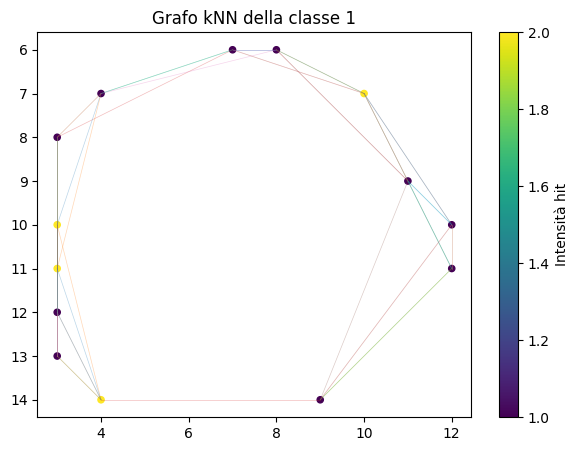

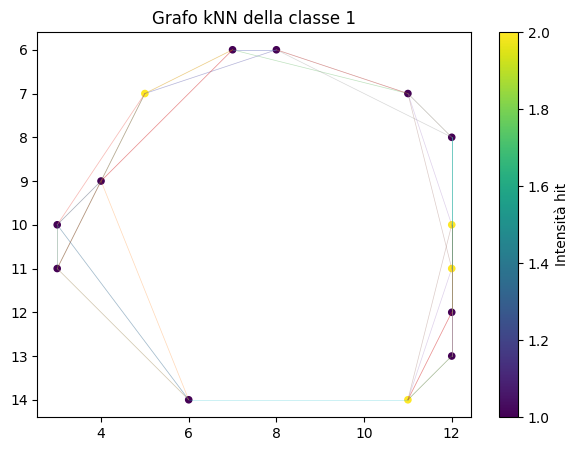

In [ ]:
# Plottiamo un esempio di data augmentation.
# Cambiamento rispetto alla CNN: mostriamo il grafo costruito dagli hit non nulli,

def build_knn_edges(pos, k=4):
    """
    Costruisce edge_index nel formato PyG [2, num_edges] usando solo PyTorch.

    pos:
      array NumPy oppure tensore PyTorch con shape [num_nodes, 2]

    Output:
      edge_index:
        tensore torch.long con shape [2, num_edges]
    """

    pos = torch.as_tensor(pos, dtype=torch.float)

    num_nodes = pos.shape[0]

    if num_nodes == 0:
        return torch.empty((2, 0), dtype=torch.long)

    # Se ci sono pochi nodi, k non può superare num_nodes - 1.
    k_eff = min(k, num_nodes - 1)

    if k_eff == 0:
        return torch.empty((2, 0), dtype=torch.long)

    # Matrice delle distanze euclidee tra tutti i nodi.
    dist = torch.cdist(pos, pos)

    # Evitiamo che un nodo scelga sé stesso come vicino.
    dist.fill_diagonal_(float("inf"))

    # Per ogni nodo, prendiamo i k vicini più prossimi.
    knn = dist.topk(k=k_eff, largest=False).indices

    # Formato PyG: edge_index[0] = sorgenti, edge_index[1] = destinazioni.
    src = torch.arange(num_nodes).repeat_interleave(k_eff)
    dst = knn.reshape(-1)

    edge_index = torch.stack([src, dst], dim=0)

    return edge_index


def image_to_graph_for_plot(image, k=4):
    """
    Converte un'immagine RICH in un grafo kNN per la sola visualizzazione.

    Nodi:
      - solo pixel/hit non nulli

    Feature:
      - intensità del pixel

    Posizione:
      - coordinate non normalizzate, usate per costruire e plottare il grafo
    """

    hit_y, hit_x = np.nonzero(image)

    pos = np.stack([hit_x, hit_y], axis=1).astype(np.float32)
    intensity = image[hit_y, hit_x].astype(np.float32)

    edge_index = build_knn_edges(pos, k=k)

    return pos, intensity, edge_index


def plot_graph_from_image(image, lab, k=4):
    pos, intensity, edge_index = image_to_graph_for_plot(image, k=k)

    plt.figure(figsize=(7, 5))

    if pos.shape[0] == 0:
        plt.title("Nessun hit non nullo nella classe {}".format(np.argmax(lab)))
        plt.axis("off")
        plt.show()
        return

    # Disegno gli archi del grafo kNN.
    for src, dst in edge_index.t().numpy():
        plt.plot(
            [pos[src, 0], pos[dst, 0]],
            [pos[src, 1], pos[dst, 1]],
            linewidth=0.5,
            alpha=0.3
        )

    # Disegno i nodi. Il colore rappresenta l'intensità dell'hit.
    plt.scatter(
        pos[:, 0],
        pos[:, 1],
        c=intensity,
        s=20,
        cmap="viridis"
    )

    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.colorbar(label="Intensità hit")
    plt.title("Grafo kNN della classe {}".format(np.argmax(lab)))
    plt.show()


image = x_all[10, :, :]
lab = y_all[10]

plot_graph_from_image(image, lab, k=4)
plot_graph_from_image(flip_hit(image), lab, k=4)

In [ ]:
# splittiamo ora il dataset e creiamo i dataset e dataloader

from sklearn.model_selection import train_test_split
X, X_test, y, y_test = train_test_split(x_all, y_all, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Cambiamento rispetto alla CNN: il Dataset produce oggetti Data di torch_geometric.
train_dataset = HitGraphGenerator(X_train, y_train, AUGMENT=True, k=4)
train_loader = BalancedDataLoader(train_dataset, batch_size=256, shuffle=True)

val_dataset = HitGraphGenerator(X_val,y_val, k=4)
val_loader = BalancedDataLoader(val_dataset, batch_size=256, shuffle=False)

test_dataset = HitGraphGenerator(X_test,y_test, k=4)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False) #non usiamo il balanced generator per il test. (evita leaks dal training set)


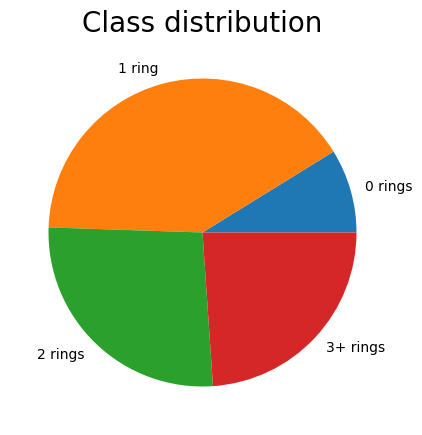

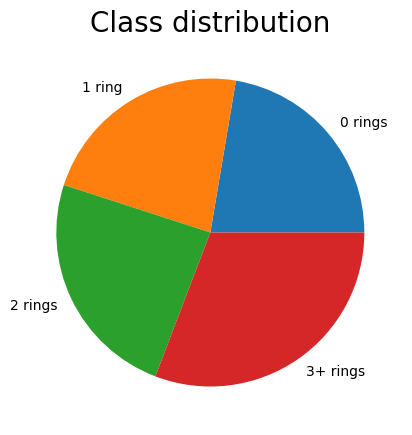

In [ ]:
# controlliamo che il balancing stia funzionando

balanced  =[]
notbalanced=[]
tmp_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Cambiamento rispetto alla CNN: il loader restituisce una Batch PyG; le label sono in batch.y.
for batch in train_loader:
  balanced.extend(batch.y.numpy())
for batch in tmp_loader:
  notbalanced.extend(batch.y.numpy())

piechartclasses(notbalanced)    #con dataloader non bilanciato
piechartclasses(balanced)       #con dataloader bilanciato


Numero di grafi nella batch: 8
Numero totale di nodi nella batch: 88
Numero totale di archi nella batch: 352
Archi tra componenti diverse: 0


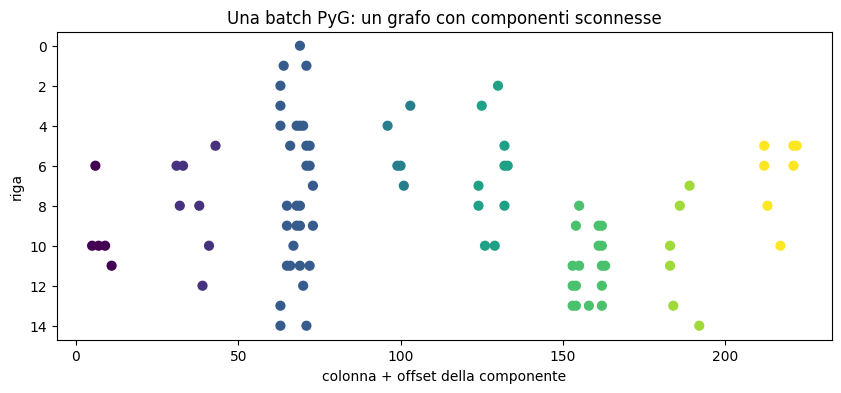

In [ ]:
# Visualizziamo una batch PyG: una batch è un unico grafo con componenti sconnesse.
# Ogni componente corrisponde a un evento RICH; batch.batch indica a quale evento appartiene ogni nodo.

batch_example = next(iter(DataLoader(train_dataset, batch_size=8, shuffle=True)))

edge_index = batch_example.edge_index
src_component = batch_example.batch[edge_index[0]]
dst_component = batch_example.batch[edge_index[1]]
print("Numero di grafi nella batch:", batch_example.num_graphs)
print("Numero totale di nodi nella batch:", batch_example.num_nodes)
print("Numero totale di archi nella batch:", batch_example.num_edges)
print("Archi tra componenti diverse:", int((src_component != dst_component).sum()))

# Per rendere visibili le componenti, applichiamo solo nel plot un offset orizzontale diverso a ogni grafo.
pos = batch_example.pos.numpy()
component = batch_example.batch.numpy()

plt.figure(figsize=(10,4))
plt.scatter(pos[:,1] + 30*component, pos[:,0], c=component, s=40)
plt.gca().invert_yaxis()
plt.xlabel("colonna + offset della componente")
plt.ylabel("riga")
plt.title("Una batch PyG: un grafo con componenti sconnesse")
plt.show()
